In [40]:
import os.path
import logging
import matplotlib
from matplotlib import pyplot as plt
import numpy as np

from utils.general_functions import load_dict
from meta import paths

# -------------------------
# Logging
# -------------------------
logging.basicConfig(format='%(levelname)s:%(message)s', level=logging.INFO)

# -------------------------
# Matplotlib settings
# -------------------------
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Bitstream Vera Sans",
    "font.size": 10.0,
    "text.latex.preamble": r"\usepackage{upgreek}",
    "mathtext.fontset": "custom",
    "mathtext.rm": "Bitstream Vera Serif",
    "mathtext.it": "Bitstream Vera Serif:italic",
    "mathtext.bf": "Bitstream Vera Serif:bold"
})

# -------------------------
# Colors
# -------------------------
cm = 1 / 2.54
colors = [
    "tab:pink", "tab:purple", "tab:blue", "tab:cyan",
    "tab:green", "tab:olive", "tab:red", "tab:orange"
]

In [41]:
# -------------------------
# Load results
# -------------------------
results = load_dict("PF_comparison.json")
materials = results["materials"]  # dict of materials

# Collect all radii (strings in JSON → convert back to float)
radii = sorted({float(R) for mat in materials.values() for R in mat.keys()})

INFO:font.family must be one of (serif, sans-serif, cursive, monospace) when text.usetex is True. serif will be used by default.
INFO:font.family must be one of (serif, sans-serif, cursive, monospace) when text.usetex is True. serif will be used by default.
INFO:font.family must be one of (serif, sans-serif, cursive, monospace) when text.usetex is True. serif will be used by default.
INFO:font.family must be one of (serif, sans-serif, cursive, monospace) when text.usetex is True. serif will be used by default.
INFO:font.family must be one of (serif, sans-serif, cursive, monospace) when text.usetex is True. serif will be used by default.
INFO:font.family must be one of (serif, sans-serif, cursive, monospace) when text.usetex is True. serif will be used by default.
INFO:font.family must be one of (serif, sans-serif, cursive, monospace) when text.usetex is True. serif will be used by default.
INFO:font.family must be one of (serif, sans-serif, cursive, monospace) when text.usetex is True.

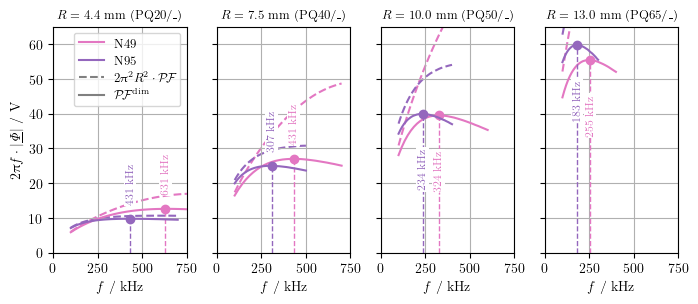

In [51]:
# -------------------------
# Figure setup
# -------------------------
fig, axes = plt.subplots(
    nrows=1, ncols=len(radii),
    figsize=(18 * cm, 8 * cm),
    sharey=True
)
max_y_tick = 65

if len(radii) == 1:
    axes = [axes]  # make iterable if only one radius

# -------------------------
# Plot curves per radius and mark optima
# -------------------------
for r_idx, R in enumerate(radii):
    ax = axes[r_idx]

    # Get core type for this radius (take from first material)
    any_mat_name = list(materials.keys())[0]
    core_label = materials[any_mat_name][str(R)]["core_type"]

    for i, (mat_name, mat_data) in enumerate(materials.items()):
        freqs = np.array(mat_data[str(R)]["frequencies"])
        PF_dim = np.array(mat_data[str(R)]["PF_dim"])
        PF_static = np.array(mat_data[str(R)]["PF_static"])

        # Safety check: ensure x and y have the same length
        min_len = min(len(freqs), len(PF_dim))
        freqs = freqs[:min_len]
        PF_dim = PF_dim[:min_len]
        PF_static = PF_static[:min_len]

        ax.plot(freqs / 1000, PF_dim, label=mat_name,
                color=colors[i % len(colors)])
        ax.plot(freqs / 1000, PF_static, "--",
                color=colors[i % len(colors)], zorder=0)

        # Mark optimum
        idx_max = np.argmax(PF_dim)
        f_opt = freqs[idx_max] / 1000  # kHz
        PF_opt = PF_dim[idx_max]
        ax.plot(f_opt, PF_opt, marker="o", color=colors[i % len(colors)], markersize=6)

        # Draw vertical line down to zero
        ax.vlines(f_opt, 0, PF_opt, color=colors[i % len(colors)], linestyle="--", lw=1)

        # Place label on the line with white background
        if PF_opt > max_y_tick / 2:
            pos_of_label = PF_opt - 10
            vertical_alignment = "top"
        else:
            pos_of_label = PF_opt + 4
            vertical_alignment = "bottom"

        ax.text(
            f_opt, pos_of_label,
            f"{int(round(f_opt))} kHz",
            color=colors[i % len(colors)],
            fontsize=8,
            ha="center",
            va=vertical_alignment,
            rotation=90,
            bbox=dict(facecolor='white', edgecolor='none', pad=1)
        )

    # Axes formatting
    ax.set_xlim((0, 750))
    ax.set_ylim((0, max_y_tick))
    ax.set_xticks([0, 250, 500, 750])
    ax.set_xlabel(r"$f$ / kHz")
    ax.set_title(f"$R = {R * 1000:.1f}$ mm ({core_label}/_)", fontsize=9)  # include core type
    ax.grid()
    # ax.legend(ncols=1, loc="upper right", fontsize=8)

    if r_idx == 0:
        handles, labels = ax.get_legend_handles_labels()
        ax.plot([], [], "--", color="gray", label=r"$2\uppi^2 R^2 \cdot \mathcal{P}\!\mathcal{F}$")
        ax.plot([], [], color="gray", label=r"$\mathcal{P}\!\mathcal{F}^\mathrm{dim}$")
        ax.legend(ncol=1, fontsize=9)

# -------------------------
# Common labels and unified legend
# -------------------------
# axes[0].set_ylabel(r"$\mathcal{P}\!\mathcal{F}^\mathrm{dim}$ / V")
axes[0].set_ylabel(r"$2 \uppi  f \cdot |\underline{\mathit{\Phi}}|$ / V")
# legend_labels = materials.keys()
# fig.legend(
#     handles, labels,
#     loc="upper center",
#     ncol=2*len(materials),
#     bbox_to_anchor=(0.5, -0.15),
#     fontsize=9
# )

# -------------------------
# Save + show
# -------------------------
plt.tight_layout()
# plt.savefig(os.path.join("PF_comparison_materials.pdf"))
plt.savefig(os.path.join(paths.grafics, "PF_comparison_materials.pdf"))
plt.show()